Cellule 1: Imports et Configuration

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
import time
import requests
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import json

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Import from Chatbot.py
try:
    from Chatbot import (
        assessment_questions,
        get_stress_level_with_ollama_api,
        get_chat_response_with_emotion,
        model_mapping
    )
    print("✓ Successfully imported from Chatbot.py")
    print(f"📋 Available models: {list(model_mapping.keys())}")
except ImportError as e:
    print(f"❌ Could not import from Chatbot.py: {e}")

✓ Successfully imported from Chatbot.py
📋 Available models: ['gemma', 'llama3.1', 'qwen3', 'deepseek']


Cellule 2: Génération des Scénarios de Test

In [3]:
def generate_test_scenarios():
    """Generate test scenarios with known stress levels"""
    scenarios = []
    
    # Very Low Stress (Level 1) - 5 scenarios
    low_stress_scenarios = [
        {
            'target_stress': 1,
            'description': 'Happy, healthy person',
            'responses': [" Very good", "Yes", "Very good", "Very high", "Very good", 
                        "Always", "Never", "Very positive", "Completely", "Never"]
        },
        {
            'target_stress': 1,
            'description': 'Optimistic person with good health',
            'responses': [" Good", "Yes", "Good", "High", "Good", 
                        "Often", "Rarely", "Positive", "Mostly", "Never"]
        },
        {
            'target_stress': 1,
            'description': 'Well-adjusted individual',
            'responses': [" Very good", "Yes", "Good", "High", "Very good", 
                        "Often", "Never", "Positive", "Completely", "Never"]
        },
        {
            'target_stress': 1,
            'description': 'Energetic and positive',
            'responses': [" Good", "Yes", "Very good", "Very high", "Good", 
                        "Always", "Rarely", "Very positive", "Mostly", "Never"]
        },
        {
            'target_stress': 1,
            'description': 'Satisfied and balanced',
            'responses': [" Very good", "Yes", "Good", "High", "Good", 
                        "Often", "Never", "Positive", "Completely", "Never"]
        }
    ]
    
    # Low-Moderate Stress (Level 2) - 5 scenarios
    moderate_low_scenarios = [
        {
            'target_stress': 2,
            'description': 'Mostly good with minor concerns',
            'responses': [" Good", "Yes", "Average", "Moderate", "Good", 
                        "Sometimes", "Sometimes", "Positive", "Mostly", "Never"]
        },
        {
            'target_stress': 2,
            'description': 'Generally positive but some stress',
            'responses': [" Neutral", "Yes", "Good", "High", "Average", 
                        "Often", "Rarely", "Positive", "Somewhat", "Never"]
        },
        {
            'target_stress': 2,
            'description': 'Mild sleep issues but overall ok',
            'responses': [" Good", "Yes", "Poor", "Moderate", "Good", 
                        "Often", "Sometimes", "Neutral", "Mostly", "Never"]
        },
        {
            'target_stress': 2,
            'description': 'Some concentration issues',
            'responses': [" Neutral", "Yes", "Good", "Moderate", "Good", 
                        "Sometimes", "Rarely", "Positive", "Somewhat", "Never"]
        },
        {
            'target_stress': 2,
            'description': 'Occasional overwhelm',
            'responses': [" Good", "Yes", "Average", "High", "Average", 
                        "Often", "Sometimes", "Positive", "Mostly", "Never"]
        }
    ]
    
    # Moderate Stress (Level 3) - 5 scenarios
    moderate_scenarios = [
        {
            'target_stress': 3,
            'description': 'Balanced stress indicators',
            'responses': [" Neutral", "No", "Average", "Moderate", "Average", 
                        "Sometimes", "Sometimes", "Neutral", "Somewhat", "Never"]
        },
        {
            'target_stress': 3,
            'description': 'Mixed responses',
            'responses': [" Bad", "Yes", "Good", "Low", "Poor", 
                        "Rarely", "Often", "Positive", "A little", "Never"]
        },
        {
            'target_stress': 3,
            'description': 'Average across most areas',
            'responses': [" Neutral", "No", "Average", "Moderate", "Average", 
                        "Sometimes", "Sometimes", "Neutral", "Somewhat", "Rarely"]
        },
        {
            'target_stress': 3,
            'description': 'Some areas good, others concerning',
            'responses': [" Good", "No", "Poor", "Moderate", "Average", 
                        "Sometimes", "Often", "Neutral", "Somewhat", "Never"]
        },
        {
            'target_stress': 3,
            'description': 'Moderate concerns',
            'responses': [" Neutral", "No", "Average", "Low", "Poor", 
                        "Rarely", "Sometimes", "Negative", "A little", "Rarely"]
        }
    ]
    
    # High Stress (Level 4) - 5 scenarios
    high_scenarios = [
        {
            'target_stress': 4,
            'description': 'Multiple stress indicators',
            'responses': [" Bad", "No", "Poor", "Low", "Poor", 
                        "Rarely", "Often", "Negative", "A little", "Sometimes"]
        },
        {
            'target_stress': 4,
            'description': 'Significant difficulties',
            'responses': [" Very bad", "No", "Average", "Very low", "Very poor", 
                        "Not at all", "Always", "Neutral", "Not at all", "Rarely"]
        },
        {
            'target_stress': 4,
            'description': 'Poor sleep and energy',
            'responses': [" Bad", "No", "Very poor", "Low", "Poor", 
                        "Sometimes", "Often", "Negative", "A little", "Sometimes"]
        },
        {
            'target_stress': 4,
            'description': 'Concentration and mood issues',
            'responses': [" Neutral", "No", "Poor", "Low", "Average", 
                        "Not at all", "Always", "Very negative", "Not at all", "Sometimes"]
        },
        {
            'target_stress': 4,
            'description': 'Multiple challenges',
            'responses': [" Bad", "No", "Poor", "Very low", "Poor", 
                        "Rarely", "Often", "Negative", "A little", "Rarely"]
        }
    ]
    
    # Very High Stress (Level 5) - 5 scenarios
    very_high_scenarios = [
        {
            'target_stress': 5,
            'description': 'Severe stress indicators',
            'responses': [" Very bad", "No", "Very poor", "Very low", "Very poor", 
                        "Not at all", "Always", "Very negative", "Not at all", "Often"]
        },
        {
            'target_stress': 5,
            'description': 'Crisis level responses',
            'responses': [" Very bad", "No", "Poor", "Very low", "Poor", 
                        "Rarely", "Always", "Very negative", "Not at all", "Always"]
        },
        {
            'target_stress': 5,
            'description': 'Multiple severe issues',
            'responses': [" Bad", "No", "Very poor", "Low", "Very poor", 
                        "Not at all", "Often", "Negative", "A little", "Often"]
        },
        {
            'target_stress': 5,
            'description': 'Overwhelming difficulties',
            'responses': [" Very bad", "No", "Poor", "Very low", "Poor", 
                        "Not at all", "Always", "Very negative", "Not at all", "Sometimes"]
        },
        {
            'target_stress': 5,
            'description': 'Severe depression indicators',
            'responses': [" Very bad", "No", "Very poor", "Very low", "Very poor", 
                        "Rarely", "Always", "Very negative", "Not at all", "Often"]
        }
    ]
    
    # Combine all scenarios
    scenarios.extend(low_stress_scenarios)
    scenarios.extend(moderate_low_scenarios)
    scenarios.extend(moderate_scenarios)
    scenarios.extend(high_scenarios)
    scenarios.extend(very_high_scenarios)
    
    return scenarios

# Generate test scenarios
test_scenarios = generate_test_scenarios()
print(f"✅ Generated {len(test_scenarios)} test scenarios")
print(f"📊 Scenarios per stress level: {len([s for s in test_scenarios if s['target_stress'] == 1])}")

# Show example scenarios
print("\n📋 Example scenarios:")
for level in range(1, 6):
    example = next(s for s in test_scenarios if s['target_stress'] == level)
    print(f"Level {level}: {example['description']}")

✅ Generated 25 test scenarios
📊 Scenarios per stress level: 5

📋 Example scenarios:
Level 1: Happy, healthy person
Level 2: Mostly good with minor concerns
Level 3: Balanced stress indicators
Level 4: Multiple stress indicators
Level 5: Severe stress indicators


Cellule 3: Vérification des Modèles Disponibles

In [4]:
def check_model_availability():
    """Check which models are actually available in Ollama"""
    try:
        response = requests.get('http://localhost:11434/api/tags', timeout=10)
        if response.status_code == 200:
            models = response.json().get('models', [])
            available_models = [model['name'] for model in models]
            print("📋 Available models in Ollama:")
            for model in available_models:
                print(f"  ✅ {model}")
            return available_models
        else:
            print("❌ Could not fetch model list from Ollama")
            return []
    except Exception as e:
        print(f"❌ Error checking models: {e}")
        return []

# Check available models
available_models = check_model_availability()
print(f"\n🎯 Found {len(available_models)} available models")

📋 Available models in Ollama:
  ✅ qwen3:8b
  ✅ deepseek-r1:7b
  ✅ llama3.1:8b
  ✅ gemma3:4b

🎯 Found 4 available models


Cellule 4: Fonction d'Évaluation d'un Seul Modèle

In [5]:
def evaluate_single_model(model_key, num_tests_per_level=5):
    """Evaluate a single model's assessment accuracy"""
    model_name = model_mapping[model_key]
    print(f"\n🔄 Evaluating Assessment Model: {model_name}")
    print("-" * 50)
    
    predictions = []
    targets = []
    response_times = []
    failed_tests = 0
    detailed_results = []
    
    # Test scenarios by stress level
    for stress_level in range(1, 6):
        level_scenarios = [s for s in test_scenarios if s['target_stress'] == stress_level]
        test_scenarios_level = level_scenarios[:num_tests_per_level]
        
        print(f"\n📊 Testing Stress Level {stress_level} ({len(test_scenarios_level)} scenarios)")
        
        for i, scenario in enumerate(test_scenarios_level):
            target = scenario['target_stress']
            responses = scenario['responses']
            description = scenario['description']
            
            print(f"  Test {i+1}: {description}...", end="")
            
            start_time = time.time()
            pred = get_stress_level_with_ollama_api(responses, model_key)
            end_time = time.time()
            
            response_time = end_time - start_time
            
            if pred is not None and 1 <= pred <= 5:
                predictions.append(pred)
                targets.append(target)
                response_times.append(response_time)
                detailed_results.append({
                    'target': target,
                    'predicted': pred,
                    'correct': pred == target,
                    'description': description,
                    'response_time': response_time
                })
                status = "✓" if pred == target else "⚠️"
                print(f" {status} Predicted: {pred}, Target: {target} ({response_time:.1f}s)")
            else:
                failed_tests += 1
                detailed_results.append({
                    'target': target,
                    'predicted': None,
                    'correct': False,
                    'description': description,
                    'response_time': 0
                })
                print(f" ❌ FAILED (pred: {pred})")
    
    if not predictions:
        print(f"❌ No successful predictions for {model_name}")
        return None
    
    # Calculate metrics
    accuracy = accuracy_score(targets, predictions)
    precision = precision_score(targets, predictions, average='weighted', zero_division=0)
    recall = recall_score(targets, predictions, average='weighted', zero_division=0)
    f1 = f1_score(targets, predictions, average='weighted', zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(targets, predictions, labels=[1, 2, 3, 4, 5])
    
    # Additional metrics
    avg_response_time = np.mean(response_times) if response_times else 0
    success_rate = len(predictions) / (len(predictions) + failed_tests)
    avg_error = np.mean([abs(p - t) for p, t in zip(predictions, targets)])
    
    # Class-wise accuracy
    class_accuracies = {}
    for stress_level in range(1, 6):
        level_targets = [t for t in targets if t == stress_level]
        level_predictions = [p for i, p in enumerate(predictions) if targets[i] == stress_level]
        
        if level_targets:
            level_accuracy = sum(1 for t, p in zip(level_targets, level_predictions) if t == p) / len(level_targets)
            class_accuracies[stress_level] = level_accuracy
        else:
            class_accuracies[stress_level] = 0.0
    
    print(f"\n📈 {model_name} Assessment Results:")
    print(f"   Success Rate: {success_rate:.1%}")
    print(f"   Overall Accuracy: {accuracy:.3f}")
    print(f"   Precision: {precision:.3f}")
    print(f"   Recall: {recall:.3f}")
    print(f"   F1 Score: {f1:.3f}")
    print(f"   Avg Error: {avg_error:.3f}")
    print(f"   Avg Response Time: {avg_response_time:.2f}s")
    print(f"   Failed Tests: {failed_tests}")
    
    print(f"\n📊 Class-wise Accuracy:")
    for level, acc in class_accuracies.items():
        status = "🟢" if acc >= 0.8 else "🟡" if acc >= 0.6 else "🔴"
        print(f"   Level {level}: {acc:.3f} {status}")
    
    return {
        'model': model_name,
        'model_key': model_key,
        'success_rate': success_rate,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'avg_error': avg_error,
        'avg_time': avg_response_time,
        'failed_tests': failed_tests,
        'class_accuracies': class_accuracies,
        'predictions': predictions,
        'targets': targets,
        'confusion_matrix': cm,
        'detailed_results': detailed_results,
        'total_tests': len(predictions) + failed_tests
    }

print("✅ Single model evaluation function ready")

✅ Single model evaluation function ready


Cellule 5: Test d'un Modèle Spécifique

In [7]:
# Test a specific model 
MODEL_TO_TEST = 'llama3.1'  # Change this to test different models

if MODEL_TO_TEST in model_mapping:
    print(f"🎯 Testing model: {model_mapping[MODEL_TO_TEST]}")
    result = evaluate_single_model(MODEL_TO_TEST, num_tests_per_level=5)
    
    if result:
        print(f"\n🎉 Evaluation completed for {result['model']}!")
        
        # Show detailed results
        correct_predictions = sum(1 for r in result['detailed_results'] if r['correct'])
        total_predictions = len([r for r in result['detailed_results'] if r['predicted'] is not None])
        
        print(f"\n📊 Detailed Results Summary:")
        print(f"   Correct predictions: {correct_predictions}/{total_predictions}")
        print(f"   Failed predictions: {result['failed_tests']}")
        
        # Show some examples
        print(f"\n📋 Example Results:")
        for i, detail in enumerate(result['detailed_results'][:10]):  # Show first 10
            status = "✅" if detail['correct'] else "❌" if detail['predicted'] is not None else "💥"
            print(f"   {i+1}. {status} Target: {detail['target']}, Pred: {detail['predicted']} - {detail['description'][:40]}...")
            
else:
    print(f"❌ Model '{MODEL_TO_TEST}' not found in model_mapping")
    print(f"Available models: {list(model_mapping.keys())}")

🎯 Testing model: llama3.1:8b

🔄 Evaluating Assessment Model: llama3.1:8b
--------------------------------------------------

📊 Testing Stress Level 1 (5 scenarios)
  Test 1: Happy, healthy person...

INFO:Chatbot:Trying stress assessment with selected model: llama3.1:8b
INFO:Chatbot:Model llama3.1:8b raw response: '2'
INFO:Chatbot:✓ Successfully extracted stress level 2 from llama3.1:8b


 ⚠️ Predicted: 2, Target: 1 (13.7s)
  Test 2: Optimistic person with good health...

INFO:Chatbot:Trying stress assessment with selected model: llama3.1:8b
INFO:Chatbot:Model llama3.1:8b raw response: '3'
INFO:Chatbot:✓ Successfully extracted stress level 3 from llama3.1:8b


 ⚠️ Predicted: 3, Target: 1 (5.1s)
  Test 3: Well-adjusted individual...

...

 ⚠️ Predicted: 4, Target: 5 (5.1s)
  Test 4: Overwhelming difficulties...

INFO:Chatbot:Trying stress assessment with selected model: llama3.1:8b
INFO:Chatbot:Model llama3.1:8b raw response: '**5**'
INFO:Chatbot:✓ Fallback extracted stress level 5 from llama3.1:8b


 ✓ Predicted: 5, Target: 5 (5.2s)
  Test 5: Severe depression indicators...

INFO:Chatbot:Trying stress assessment with selected model: llama3.1:8b
INFO:Chatbot:Model llama3.1:8b raw response: '**5**'
INFO:Chatbot:✓ Fallback extracted stress level 5 from llama3.1:8b


 ✓ Predicted: 5, Target: 5 (5.1s)

📈 llama3.1:8b Assessment Results:
   Success Rate: 92.0%
   Overall Accuracy: 0.348
   Precision: 0.291
   Recall: 0.348
   F1 Score: 0.309
   Avg Error: 0.696
   Avg Response Time: 5.45s
   Failed Tests: 2

📊 Class-wise Accuracy:
   Level 1: 0.000 🔴
   Level 2: 0.200 🔴
   Level 3: 0.200 🔴
   Level 4: 0.667 🟡
   Level 5: 0.800 🟢

🎉 Evaluation completed for llama3.1:8b!

📊 Detailed Results Summary:
   Correct predictions: 8/23
   Failed predictions: 2

📋 Example Results:
   1. ❌ Target: 1, Pred: 2 - Happy, healthy person...
   2. ❌ Target: 1, Pred: 3 - Optimistic person with good health...
   3. ❌ Target: 1, Pred: 2 - Well-adjusted individual...
   4. ❌ Target: 1, Pred: 2 - Energetic and positive...
   5. ❌ Target: 1, Pred: 2 - Satisfied and balanced...
   6. ❌ Target: 2, Pred: 3 - Mostly good with minor concerns...
   7. ✅ Target: 2, Pred: 2 - Generally positive but some stress...
   8. ❌ Target: 2, Pred: 3 - Mild sleep issues but overall ok...
   9. 

Cellule 6: Visualisation pour un Seul Modèle

c:\Users\bchal\anaconda3\envs\mindcare-ai\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\bchal\AppData\Local\Temp\ipykernel_11872\806577243.py:73: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{result["model"]}_evaluation.png', dpi=300, bbox_inches='tight')
c:\Users\bchal\anaconda3\envs\mindcare-ai\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


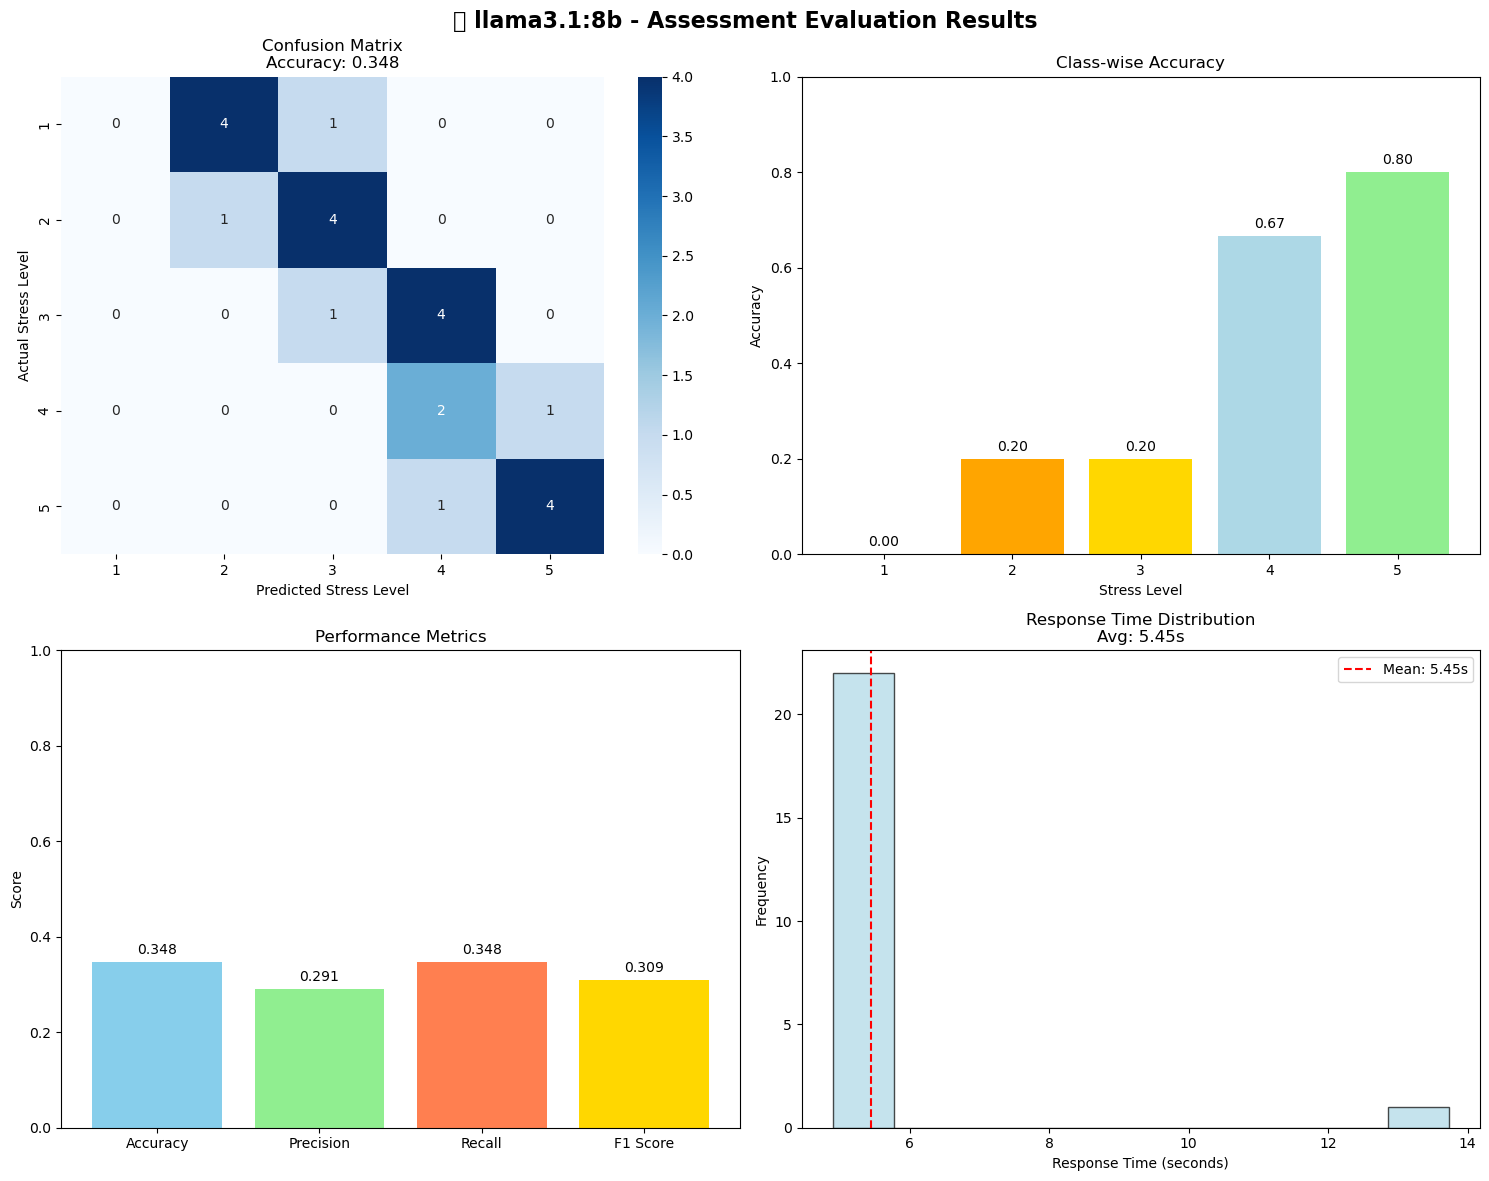


📊 llama3.1:8b Summary Statistics:
   Total Tests: 25
   Successful Tests: 23
   Failed Tests: 2
   Success Rate: 92.0%
   Best Class: Level 5 (0.800)
   Worst Class: Level 1 (0.000)


In [8]:
def create_single_model_visualization(result):
    """Create visualization for a single model evaluation"""
    if not result:
        print("❌ No result to visualize")
        return
    
    # Set up the plot style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'🤖 {result["model"]} - Assessment Evaluation Results', fontsize=16, fontweight='bold')
    
    # 1. Confusion Matrix
    sns.heatmap(result['confusion_matrix'], 
               annot=True, fmt='d', 
               xticklabels=[1, 2, 3, 4, 5], 
               yticklabels=[1, 2, 3, 4, 5],
               cmap='Blues',
               ax=axes[0, 0])
    axes[0, 0].set_title(f'Confusion Matrix\nAccuracy: {result["accuracy"]:.3f}')
    axes[0, 0].set_xlabel('Predicted Stress Level')
    axes[0, 0].set_ylabel('Actual Stress Level')
    
    # 2. Class-wise Accuracy
    stress_levels = list(range(1, 6))
    class_accs = [result['class_accuracies'].get(level, 0) for level in stress_levels]
    bars = axes[0, 1].bar(stress_levels, class_accs, 
                         color=['lightcoral', 'orange', 'gold', 'lightblue', 'lightgreen'])
    axes[0, 1].set_title('Class-wise Accuracy')
    axes[0, 1].set_xlabel('Stress Level')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].set_xticks(stress_levels)
    
    # Add value labels on bars
    for bar, acc in zip(bars, class_accs):
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{acc:.2f}', ha='center', va='bottom', fontsize=10)
    
    # 3. Metrics Summary
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    values = [result['accuracy'], result['precision'], result['recall'], result['f1']]
    bars = axes[1, 0].bar(metrics, values, color=['skyblue', 'lightgreen', 'coral', 'gold'])
    axes[1, 0].set_title('Performance Metrics')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_ylim(0, 1)
    
    # Add value labels
    for bar, value in zip(bars, values):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=10)
    
    # 4. Response Time Distribution
    response_times = [r['response_time'] for r in result['detailed_results'] if r['response_time'] > 0]
    if response_times:
        axes[1, 1].hist(response_times, bins=10, color='lightblue', alpha=0.7, edgecolor='black')
        axes[1, 1].set_title(f'Response Time Distribution\nAvg: {result["avg_time"]:.2f}s')
        axes[1, 1].set_xlabel('Response Time (seconds)')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].axvline(result["avg_time"], color='red', linestyle='--', 
                          label=f'Mean: {result["avg_time"]:.2f}s')
        axes[1, 1].legend()
    else:
        axes[1, 1].text(0.5, 0.5, 'No response time data', 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Response Time Distribution')
    
    plt.tight_layout()
    plt.savefig(f'{result["model"]}_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n📊 {result['model']} Summary Statistics:")
    print(f"   Total Tests: {result['total_tests']}")
    print(f"   Successful Tests: {len(result['predictions'])}")
    print(f"   Failed Tests: {result['failed_tests']}")
    print(f"   Success Rate: {result['success_rate']:.1%}")
    print(f"   Best Class: Level {max(result['class_accuracies'], key=result['class_accuracies'].get)} ({max(result['class_accuracies'].values()):.3f})")
    print(f"   Worst Class: Level {min(result['class_accuracies'], key=result['class_accuracies'].get)} ({min(result['class_accuracies'].values()):.3f})")

# Visualize the result if we have one
if 'result' in locals() and result:
    create_single_model_visualization(result)
else:
    print("❌ No result to visualize. Run the evaluation first.")

Cellule 7: Comparaison de Plusieurs Modèles

In [ ]:
def evaluate_multiple_models(models_to_test=None, num_tests_per_level=3):
    """Evaluate multiple models and compare results"""
    if models_to_test is None:
        models_to_test = list(model_mapping.keys())
    
    print("🚀 === MindCare-AI Multi-Model Assessment Evaluation ===")
    print(f"📌 Testing Models: {[model_mapping[m] for m in models_to_test]}")
    print(f"🎯 Test Scenarios: {num_tests_per_level} per stress level per model")
    
    all_results = []
    
    for i, model_key in enumerate(models_to_test, 1):
        print(f"\n{'='*70}")
        print(f"🔄 Evaluating Model {i}/{len(models_to_test)}: {model_mapping[model_key]}")
        
        result = evaluate_single_model(model_key, num_tests_per_level)
        if result:
            all_results.append(result)
        
        # Small delay between models
        time.sleep(1)
    
    return all_results

def display_comparison_table(results):
    """Display comparison results in a formatted table"""
    if not results:
        print("❌ No results to compare")
        return
    
    print(f"\n{'='*80}")
    print("📈 MULTI-MODEL COMPARISON RESULTS")
    print(f"{'='*80}")
    
    # Create comparison DataFrame
    comparison_data = []
    for r in results:
        comparison_data.append({
            'Model': r['model'],
            'Success Rate': f"{r['success_rate']:.1%}",
            'Accuracy': f"{r['accuracy']:.3f}",
            'Precision': f"{r['precision']:.3f}",
            'Recall': f"{r['recall']:.3f}",
            'F1 Score': f"{r['f1']:.3f}",
            'Avg Error': f"{r['avg_error']:.3f}",
            'Avg Time': f"{r['avg_time']:.1f}s",
            'Failed': r['failed_tests']
        })
    
    df = pd.DataFrame(comparison_data)
    print(df.to_string(index=False))
    
    # Best performing model
    best_model = max(results, key=lambda x: x['accuracy'])
    print(f"\n🏆 BEST PERFORMING MODEL:")
    print(f"   Model: {best_model['model']}")
    print(f"   Accuracy: {best_model['accuracy']:.3f}")
    print(f"   F1 Score: {best_model['f1']:.3f}")
    print(f"   Success Rate: {best_model['success_rate']:.1%}")
    
    return df

# Test multiple models (uncomment to run)
# MODELS_TO_TEST = ['llama3.1', 'gemma3']  # Add your available models here
# multi_results = evaluate_multiple_models(MODELS_TO_TEST, num_tests_per_level=3)
# comparison_df = display_comparison_table(multi_results)

print("✅ Multi-model evaluation functions ready")
print("💡 Uncomment the lines above to run multi-model evaluation")

In [13]:
# Nouvelle cellule dans votre notebook pour tester le nettoyage
def test_qwen3_response_cleaning():
    """Test Qwen3 response cleaning specifically"""
    
    print("🧪 Testing Qwen3 Response Cleaning")
    print("-" * 50)
    
    # Test assessment
    test_responses = [" Good", "Yes", "Average", "Moderate", "Good", 
                     "Sometimes", "Sometimes", "Positive", "Mostly", "Never"]
    
    print("📊 Testing assessment with Qwen3...")
    for i in range(3):  # Test 3 times to see consistency
        pred = get_stress_level_with_ollama_api(test_responses, 'qwen3')
        print(f"  Attempt {i+1}: Predicted stress level = {pred}")
    
    # Test chat response
    print("\n💬 Testing chat response with Qwen3...")
    test_message = "I'm feeling anxious about my upcoming presentation at work."
    chat_result = get_chat_response_with_emotion(test_message, [], 'qwen3')
    
    print(f"📝 Response length: {len(chat_result['response'])} characters")
    print(f"🎭 Emotion detected: {chat_result['emotion_detected']}")
    print(f"💡 Response preview: {chat_result['response'][:200]}...")
    
    # Check if response contains thinking patterns
    thinking_indicators = ['thinking', 'let me', 'i need to consider', 'based on']
    has_thinking = any(indicator in chat_result['response'].lower() for indicator in thinking_indicators)
    
    print(f"🧠 Contains thinking patterns: {'❌ Yes' if has_thinking else '✅ No'}")

# Run the test
test_qwen3_response_cleaning()

🧪 Testing Qwen3 Response Cleaning
--------------------------------------------------
📊 Testing assessment with Qwen3...


INFO:Chatbot:Trying stress assessment with selected model: qwen3:8b
INFO:Chatbot:Model qwen3:8b raw response: '<think>'
ERROR:Chatbot:LLM model failed - no fallback available


  Attempt 1: Predicted stress level = None


INFO:Chatbot:Trying stress assessment with selected model: qwen3:8b
INFO:Chatbot:Model qwen3:8b raw response: '<think>'
ERROR:Chatbot:LLM model failed - no fallback available


  Attempt 2: Predicted stress level = None


INFO:Chatbot:Trying stress assessment with selected model: qwen3:8b
INFO:Chatbot:Model qwen3:8b raw response: '<think>'
ERROR:Chatbot:LLM model failed - no fallback available


  Attempt 3: Predicted stress level = None

💬 Testing chat response with Qwen3...


INFO:Chatbot:Detected emotion: fear (confidence: 1.00)
INFO:Chatbot:Generating chat response with model: qwen3:8b
ERROR:Chatbot:Failed to get response from qwen3:8b


TypeError: tuple indices must be integers or slices, not str